## Mathematical modeling of aircraft runway alignment

## Introduction
This project explores the mathematical logic behind the aircraft autonomous landing where the image of a 2D camera transforms into a 3D spacial data of the runway, helping pilots visualize the landing in a more precise way.   

## Objectives:
- Define the transition between 2D pixel coordinates to 3D world coordinates, using the Perspective-n-Point(PnP) algorithm. 
- Analyze how rotation matrices and translation vectors describe the aircraft's position relative to the runway. 
- Understand the role of probability in reducing "noise" caused by aircraft vibrations and atmospheric conditions.

## Core of the problem
The main aviation challenge in vision-based landing(the one that uses a camera in order to facilitate the job of the pilot or is completely autonomous) is extracting 3D information from 2D image data in order to determine the position of the plane relative to the runway. 

## The intrinsic camera matrix. 
Intrinsic parameters of a camera are related to the camera itself, regardless of where it is placed. In order to explain how a camera perceives the three-dimensional world, we use the camera intrinsic matrix K - a 3x3 matrix that encodes the internal parameters of a camera: the focal length, known better as the "zoom"(f_x, f_y) and the principal point(c_x, c_y), which is typically the center of the image(Hartley&Zisserman, Chapter 6). The last row [0, 0, 1] is always fixed, required by the rules and laws of the projective geometry(Hartley&Zisserman, Chapter 2). K defines the relationship between 3D coordinates and their 2D  projections in the camera image. In the context of autonomous landing, K tells us exactly how a point on the runway appears as a pixel in the camera image. 


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Camera intrinsic matrix K
f = 800        # focal length in pixels
cx = 320  # principal point (image center)
cy = 240  # principal point (image center)

K = np.array([[f, 0, cx],
              [0, f, cy],
              [0, 0,  1]])

print("Camera Matrix K:")
print(K)

Camera Matrix K:
[[800   0 320]
 [  0 800 240]
 [  0   0   1]]


Now we will visualize how a 3D point on the runway is projected onto the 2D image plane using K: 

3D point: [ 1.   0.5 10. ]
2D projection: (400.0, 280.0) pixels


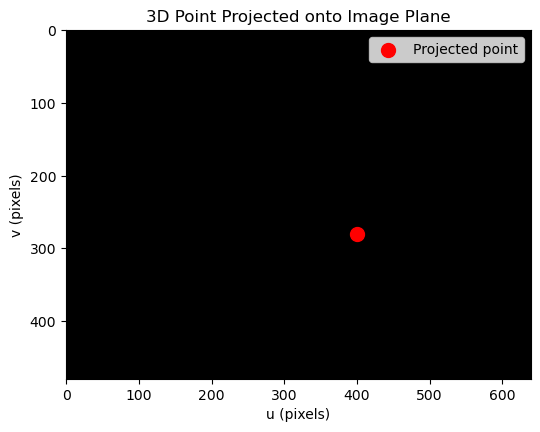

In [3]:
# Define a 3D point on the runway (X, Y, Z in meters)
point_3d = np.array([1.0, 0.5, 10.0])  # 10 meters ahead

# Project to 2D using K
point_homogeneous = K @ point_3d
u = point_homogeneous[0] / point_homogeneous[2]
v = point_homogeneous[1] / point_homogeneous[2]

print(f"3D point: {point_3d}")
print(f"2D projection: ({u:.1f}, {v:.1f}) pixels")

# Visualize
plt.figure(figsize=(6, 5))
plt.imshow(np.zeros((480, 640)), cmap='gray')
plt.scatter(u, v, color='red', s=100, label='Projected point')
plt.title('3D Point Projected onto Image Plane')
plt.xlabel('u (pixels)')
plt.ylabel('v (pixels)')
plt.legend()
plt.show()

The visualization that we see is a simulation of a real, possible case in the field of the aviation. The red dot represents the 3D point on the runway projected in 2D. We took for example a realistic distance of 10 meters between the aircraft and the runway. Тhe red dot is located at pixel coordinates 400 and 280, offset from the center because of the given data - 1 meter to the right and 0.5 meters above the camera center. 

## Rotation matrix and translation vector
While flying, the aircraft has its own position in the air, which is called translation and its rotation, which depends on the current angle of the plane. According to the Pilot's Handbook of Aeronautical Knowledge (PHAK, Chapter 5), an aircraft moves about three axes of rotation: roll, pitch, and yaw. In that case, according to Hartley & Zisserman,  we analyze the translation with the vector t, using x, y, z in meters. The rotation is a 3x3 matrix, which we will call R. 

In [4]:
import numpy as np

# Translation vector t - position of aircraft
# 10 meters ahead, 0 meters sideways, 5 meters above runway
t = np.array([0, 0, 10.0])

# Rotation matrix R - identity matrix means no rotation
# Aircraft is perfectly aligned with the runway
R = np.eye(3)

print("Translation vector t (meters):")
print(t)
print("\nRotation matrix R:")
print(R)

Translation vector t (meters):
[ 0.  0. 10.]

Rotation matrix R:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In this code, we see that R is equivalent to np.eye(3), which gives us an identity matrix or no rotation. The identity matrix is a fundamental concept in linear algebra, according to which multiplying any matrix by the identity matrix, leaves it unchanged, just like multiplying a number by 1. In the context of rotation, this means no change in orientation. This is the perfect case for a perfect landing. But in reality, nothing is so perfect, which leads us to the conclusion that this case is practically impossible in the real world. This ideal but impossible case serves us to understand why PnP(Perspective-n-Point) is necessary in real landing scenarios(Lepetit et al., 2009; Xin et al., 2022).

## The Perspective-n-Point(PnP) problem
The PnP problem arises when we need to determine the 3D position of the plane, using a 2D image. As we have seen, the vector t and the matrix R can determine that position but they would be enough only in perfect and impossible cases. For that reason, the PnP algorithm uses n points in the image in order to find the "realistic" position of t and R(Lepetit et al., 2009).


In [5]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [6]:
import cv2
import numpy as np

# 3D points on the runway (world coordinates in meters)
runway_points_3d = np.array([
    [-10, 0, 50],   # left corner far
    [ 10, 0, 50],   # right corner far
    [-10, 0, 20],   # left corner near
    [ 10, 0, 20],   # right corner near
], dtype=np.float32)

# Corresponding 2D points in the image (pixels)
runway_points_2d = np.array([
    [220, 180],   # left corner far
    [420, 180],   # right corner far
    [160, 280],   # left corner near
    [480, 280],   # right corner near
], dtype=np.float32)

# Solve PnP
success, rvec, tvec = cv2.solvePnP(
    runway_points_3d, runway_points_2d, K, None)

print("Rotation vector:")
print(rvec)
print("\nTranslation vector:")
print(tvec)

Rotation vector:
[[ 2.84594110e-01]
 [-5.01761082e-19]
 [ 4.18210558e-18]]

Translation vector:
[[6.28892860e-16]
 [8.12152263e+00]
 [3.09660130e+01]]


As we can see from the code above, the PnP algorithm works with 4 correspondence points - the corners of the runway. Instead of measuring all possible points from the 2D image, it takes only 4 to calculate the position and orientation of the aircraft. In this code, the function cv2.solvePnP returns three values: the first, called "success" is a boolean value that confirms whether the algorithm found a valid solution. The second, "rvec"(rotation vector), is a compact representation of the rotation - it just encodes the axis and the angle of rotation as 3 numbers, known as Rodrigues vector(Lepetit et al., 2009). The third, "tvec"(translation vector), gives us the position of the camera in 3D space in meters. 

## Conclusion 
This project explored the mathematical foundations of autonomous landing in modern aviation. Starting from the intrinsic matrix K, which defines how a 3D point on the runway is projected onto a 2D image, we then analyzed the rotation matrix R and translation vector t, which describe the position and orientation of the aircraft. Since we came to realize that a perfect alignment of the aircraft during landing is nearly impossible, we demonstrated how the Perspective-n-Point(PnP) algorithm uses 4 correspondence points to calculate the realistic position and orientation of the aircraft relative to the runway. 